In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from copy import deepcopy

In [3]:
flav = "easy-gamma"
hep = False

if hep:
    fit_name = f'hep/{flav}'
else:
    fit_name = flav
 
path = f'fit-results/{fit_name}/'
path

NBINS = 31
WIDTH = 0.3

In [4]:
# useful for both plots
# indices for which we plot the ratio plot (= nbins)
if hep:
    #ymeas = np.load(path+'ymeas.npy')
    xmeas = np.load(path+'xmeas.npy')
    xmeas = (xmeas - np.min(xmeas)) / (np.max(xmeas) - np.min(xmeas))
    m_xmeas = np.load(path+'m_xmeas.npy')
    NBINS=35
    #LHC_gan = np.load(path+'LHC_gan.npy')
else:
    ratio_idx = np.load(path+'ratio_idx.npy')

# times array
xarr = np.load(path+'xarr.npy')
# sample
sample = np.load(path+'sample.npy')
# corrected means (peaks removed)
new_noisy_de = np.load(path+'new_noisy_de.npy')
noisy_de_raw = np.load(path+'noisy_de.npy')
very_noisy_de_raw = np.load(path+'very_noisy_de.npy')

best_p = np.load(path+'best_p.npy')
nruns = np.load(path+'nruns.npy')
nshots = np.load(path+'nshots.npy')
#final_loss = np.load(path+'final_loss.npy')

# useful for PDF plot
# derivative of the energy, exact simulation
de = np.load(path+'de.npy')
# derivative of the energy, noisy simulation
m_noisy_de = np.load(path+'m_noisy_de.npy')
#s_noisy_de = np.load(path+'s_noisy_de.npy')
# derivative of the energy, true law
labels = np.load(path+'labels.npy')
# values of the means of the ratios between estimated noisy de and true law
ratio = np.load(path+'ratio.npy')
# sigmas of the means of previous ratios
sigmas = np.load(path+'sigmas.npy')

if True:
    ratio_queue = np.load(path+'ratio_queue.npy')
    sigma_queue = np.load(path+'sigma_queue.npy')

# useful for CDF plot
# energy, exact simulation
e = np.load(path+'e.npy')
# energy, noisy simulation
m_noisy_e = np.load(path+'m_noisy_e.npy')
noisy_e = np.load(path+'noisy_e.npy')
# energy, true law
e_labels = np.load(path+'e_labels.npy')
# values of the means of the ratios between estimated noisy e and true law
e_ratio = np.load(path+'e_ratio.npy')
# sigmas of the means of previous ratios
e_sigmas = np.load(path+'e_sigmas.npy')

if True:
    ratio_queue_e = np.load(path+'ratio_queue_e.npy')
    sigma_queue_e = np.load(path+'sigma_queue_e.npy')
    
normed_sample = sample

In [5]:
# ensure I am approximating a probability distribution
np.trapz(de, xarr)

1.0000370946672323

In [6]:
Nshots = [r"$N_{shots}=2\cdot 10^{4}$", r"$N_{shots}=2\cdot 10^{5}$"]
lines = ['-', '-']
idx = [1, 3]

In [7]:
gamma_label = r"Gamma"
gauss_label = r"Gaussian mixture"
y_label = r'$y$ in $pp\to t\bar{t}$ decay'
t_label = r'$t$ in $pp\to t\bar{t}$ decay'
s_label = r'$s$ in $pp\to t\bar{t}$ decay'

if "gamma" in fit_name:
    lab = "gamma"
    plot_label = gamma_label
if "multi-gauss" in fit_name:
    lab = "gauss"
    plot_label = gauss_label
if fit_name == "hep/rapidity":
    lab = "y"
    plot_label = y_label
if fit_name == "hep/t":
    lab = "t"
    plot_label = t_label
if fit_name == "hep/s":
    lab = "s"
    plot_label = s_label

save_as = f"{lab}_{str(len(best_p))}_{str(nruns)}_{nshots}"

In [8]:
def create_box_collection(x, ymax, ymin, color, alpha=0.3):
    """ Given an array (evenly spaced) in x
    and the corresponding y values (and their error) create a collection of boxes to be plotted
    This function assumes that the given value of x is the upper bound of the box.
    """
    xmax = x
    xmin = np.concatenate([[0.0], x[:-1]])
    #ymin = y - s
    #ymax = y + s
    
    # Generate the array of rectangles
    r = []
    for xm, xp,   ym, yp in zip(xmin,xmax,ymin,ymax):
        r.append(
            Rectangle(
                (xm, ym), # x, u
                (xp-xm), # width
                (yp-ym), # height
            )
        )
    return PatchCollection(r, facecolor=color, edgecolor=None, alpha=0.3)

In [9]:
noisy_de_raw.shape

(20, 501)

2/501 elements are been corrected.


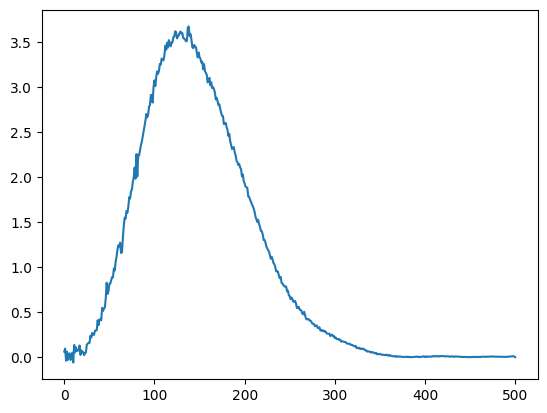

In [23]:
def smoothing(array_raw, epsilon=2e-1):
    array = array_raw.T
    new = []
    counter = 0
    new.append(array[0])
    for idx in range(1, len(array)-2, 1):
        prev_value = new[-1]

        for i in range(20):
            new_number = (array[idx+i] + array[idx-i])/2

            if np.abs(np.mean(new_number - prev_value)) < epsilon:
                break

            counter += 1
        
        new.append(new_number)

    new.append(array[-2])
    new.append(array[-1])
    print(f'{counter}/{len(array)} elements are been corrected.')
    np.save(arr=counter, file=path+'n_corrections')
    return np.array(new).T

noisy_de = smoothing(noisy_de_raw)
plt.plot(np.mean(noisy_de_raw, axis=0))

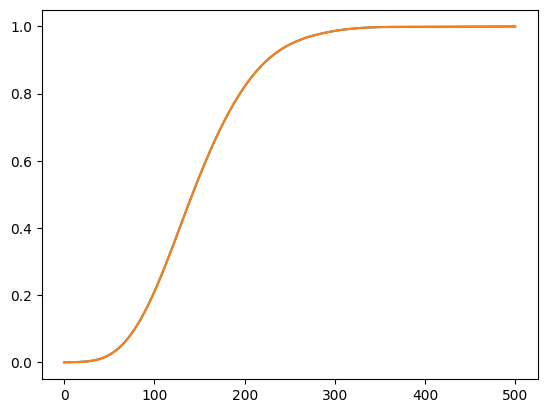

In [11]:
e = -e
noisy_me = np.mean(noisy_e, axis=0)

for i, (el, nel) in enumerate(zip(e, noisy_me)):
    if np.abs(el) >= 0.3 and el < 0:
        e[i] *= -1
    if np.abs(nel) >= 0.3 and nel < 0:
        noisy_me[i] *= -1    

plt.plot(e)
plt.plot(noisy_me)

## Compute metrics: MSE and KL divergence

Shot-noise de 0.003895448054824764
Shot-noise de 1 run 0.014793995185373023
Exact de 0.002226822639430532
Shot-noise e 7.395569366633716e-05
Shot-noise e 1 run 0.0001993611045390067
Exact e 6.338733075838404e-05


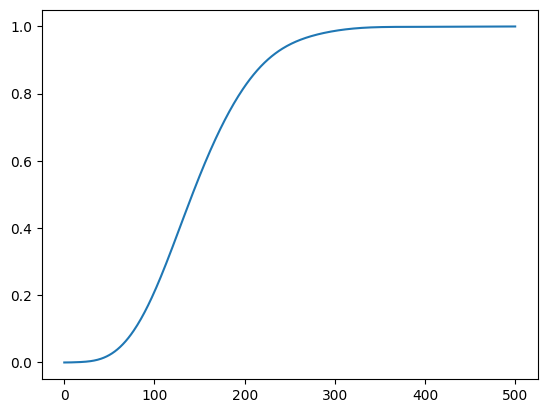

In [14]:
def metric(l, e, method="mse"):
    # Ensure inputs are numpy arrays
    l = np.asarray(l)
    e = np.asarray(e)
    
    if method == "mse":
        return np.sum((np.abs(l)[1:] - np.abs(e)[1:])**2) / len(np.abs(l)[1:])
    
    elif method == "KL":
        # Normalize l and e to ensure they represent probability distributions
        l_normalized = np.abs(l)[1:] / np.sum(np.abs(l)[1:])
        e_normalized = np.abs(e)[1:] / np.sum(np.abs(e)[1:])
        
        # Handle zero values to avoid log(0)
        # Use np.where to avoid calculating log of zero probabilities
        return np.sum(np.where(e_normalized != 0, 
                               e_normalized * np.log(e_normalized / l_normalized), 
                               0))


# set the method here
meth = "KL"

if not hep:
    print("Shot-noise de", metric(np.mean(noisy_de_raw, axis=0), labels, method=meth))
    print("Shot-noise de 1 run", metric(noisy_de_raw[1], labels, method=meth))
    print("Exact de", metric(de, labels, method=meth))
    print("Shot-noise e", metric(np.mean(noisy_e, axis=0), e_labels, method=meth))
    print("Shot-noise e 1 run", metric(noisy_e[1], e_labels, method=meth))
    print("Exact e", metric(e, e_labels, method=meth))
    plt.plot(e)

In [15]:
de[0] * np.log(de[0]/e_labels[0])

de[2], e_labels[2]

/tmp/ipykernel_104128/1163287625.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  de[0] * np.log(de[0]/e_labels[0])
/tmp/ipykernel_104128/1163287625.py:1: RuntimeWarning: invalid value encountered in log
  de[0] * np.log(de[0]/e_labels[0])


(0.01057874741696336, 1.5389589861697756e-05)

In [24]:
# Get the average and the limits of noisy_de
#noisy_de = np.concatenate([new_noisy_de, [0.0]])

def generate_quanties(noisy_de_inp, labels_input=None):
    """Generate all necessary quantities from an array of results
    (nruns x nx)
    This functio accepts also a set of true labels of the same size
    (in nx) as noisy_de_inp. If one doesn't have such true labels
    all quantities will be computed as the total result (no ratios taken)
    """
    #noisy_de = smoothing(noisy_de_inp)
    noisy_de = noisy_de_inp

    epsilon = 1e-8 # Add a very small epsilon in case of 0s
    sigma_noisy = np.std(noisy_de, axis=0) + epsilon
    central_noisy = np.average(noisy_de, axis=0) + epsilon
    noisy_min = central_noisy - sigma_noisy + epsilon
    noisy_max = central_noisy + sigma_noisy + epsilon
    exact = de + epsilon
    if labels_input is None:
        true_labels = 1.0
    else:
        true_labels = labels + epsilon

    # Get also the ratios
    ratio_central = central_noisy / true_labels
    ratio_max = noisy_max / true_labels
    ratio_min = noisy_min / true_labels

    # Now integrate all 3
    int_central = []
    int_max = []
    int_min = []
    # And the exact simulation as well
    exact_ratio = exact/true_labels
    int_exact = []

    # Now, integrate. Let's integrate using bins of different sizes.
    # Basically, up to ~0.1 and from ~0.5 onwards the bins will be bigger
    xleft = 0
    idx = []
    #for xright in (ratio_idx[1:]):
    for xright in np.linspace(0, len(xarr), NBINS, dtype=int):
        if xright == 0:
            continue
        # Check at what x are wee
        int_central.append(np.average(ratio_central[xleft:xright]))
        int_max.append(np.average(ratio_max[xleft:xright]))
        int_min.append(np.average(ratio_min[xleft:xright]))
        int_exact.append(np.average(exact_ratio[xleft:xright]))
        
        idx.append(int( (xright+xleft)/2 ))
        xleft = xright

    # noises
    int_noise_min = []
    int_noise_max = []
    idx_noise = []
    xleft = 0
    for xright in np.linspace(0, len(xarr), NBINS, dtype=int):
        if xright == 0:
            continue
        int_noise_min.append(np.average(noisy_min[xleft:xright]))
        int_noise_max.append(np.average(noisy_max[xleft:xright]))
        idx_noise.append(int( (xright+xleft)/2 ))
        xleft = xright

    idx_noise[0] = 0
    idx_noise = np.array(idx_noise)

    idx = np.array(idx)
    int_central = np.array(int_central)
    int_max = np.array(int_max)
    int_min = np.array(int_min)

    return idx_noise, int_noise_min, int_noise_max, idx, int_central, int_max, int_min, int_exact

def generate_cdf_quanties(noisy_de_inp, labels_input=None):
    """Generate all necessary quantities from an array of results
    (nruns x nx)
    This functio accepts also a set of true labels of the same size
    (in nx) as noisy_de_inp. If one doesn't have such true labels
    all quantities will be computed as the total result (no ratios taken)
    """
    #noisy_de = smoothing(noisy_de_inp)
    noisy_de = noisy_de_inp
    
    epsilon = 1e-8 # Add a very small epsilon in case of 0s
    sigma_noisy = np.std(noisy_de, axis=0) + epsilon
    central_noisy = np.average(noisy_de, axis=0) + epsilon
    noisy_min = central_noisy - sigma_noisy + epsilon
    noisy_max = central_noisy + sigma_noisy + epsilon
    exact = e + epsilon
    if labels_input is None:
        true_labels = 1.0
    else:
        true_labels = e_labels + epsilon

    # Get also the ratios
    ratio_central = central_noisy / true_labels
    ratio_max = noisy_max / true_labels
    ratio_min = noisy_min / true_labels

    # Now integrate all 3
    int_central = []
    int_max = []
    int_min = []
    # And the exact simulation as well
    exact_ratio = exact/true_labels
    int_exact = []

    # Now, integrate. Let's integrate using bins of different sizes.
    # Basically, up to ~0.1 and from ~0.5 onwards the bins will be bigger
    xleft = 0
    idx = []
    #for xright in (ratio_idx[1:]):
    for xright in np.linspace(0, len(xarr), NBINS, dtype=int):
        if xright == 0:
            continue
        # Check at what x are wee
        int_central.append(np.average(ratio_central[xleft:xright]))
        int_max.append(np.average(ratio_max[xleft:xright]))
        int_min.append(np.average(ratio_min[xleft:xright]))
        int_exact.append(np.average(exact_ratio[xleft:xright]))
        
        idx.append(int( (xright+xleft)/2 ))
        xleft = xright

    # noises
    int_noise_min = []
    int_noise_max = []
    idx_noise = []
    xleft = 0
    for xright in np.linspace(0, len(xarr), NBINS, dtype=int):
        if xright == 0:
            continue
        int_noise_min.append(np.average(noisy_min[xleft:xright]))
        int_noise_max.append(np.average(noisy_max[xleft:xright]))
        idx_noise.append(int( (xright+xleft)/2 ))
        xleft = xright

    idx_noise[0] = 0
    idx_noise = np.array(idx_noise)

    idx = np.array(idx)
    int_central = np.array(int_central)
    int_max = np.array(int_max)
    int_min = np.array(int_min)

    return idx_noise, int_noise_min, int_noise_max, idx, int_central, int_max, int_min, int_exact

if hep:
    idx_noise, int_noise_min, int_noise_max, idx, int_central, int_max, int_min, int_exact = generate_quanties(noisy_de_raw)
    _, _, _, _, cdf_central, _, _, cdf_exact = generate_cdf_quanties(noisy_e)
    _, _, _, _, int_central_2, int_max_2, int_min_2, _ = generate_quanties(very_noisy_de_raw)

    pdf_central = deepcopy(int_central)
    pdf_exact = deepcopy(int_exact)
    
    int_central /= labels
    int_max /= labels
    int_min /= labels
    int_exact /= labels

    int_central_2 /= labels
    int_max_2 /= labels
    int_min_2 /= labels
else:
    idx_noise, int_noise_min, int_noise_max, idx, int_central, int_max, int_min, int_exact = generate_quanties(noisy_de_raw, labels_input=labels)
    _, _, _, _, int_central_2, int_max_2, int_min_2, _ = generate_quanties(very_noisy_de_raw, labels_input=labels)

integrated_central = [int_central_2, int_central]
integrated_min = [int_min_2, int_min]
integrated_max = [int_max_2, int_max]

In [25]:
if hep:
    plt.plot(pdf_central)
    plt.plot(pdf_exact)
    plt.plot(labels)
    plt.show()

    np.save(file=path+"cdf_central_plot", arr=cdf_central)
    np.save(file=path+"cdf_exact_plot", arr=cdf_exact)
    np.save(file=path+"pdf_central_plot", arr=pdf_central)
    np.save(file=path+"pdf_exact_plot", arr=pdf_exact)


    meth="KL"


    print("Shot-noise de", metric(pdf_central, labels, method=meth))
    print("Exact de", metric(pdf_exact, labels, method=meth))
    print("Shot-noise e", metric(cdf_central, e_labels, method=meth))
    print("Exact e", metric(cdf_exact, e_labels, method=meth))
    plt.plot(e)

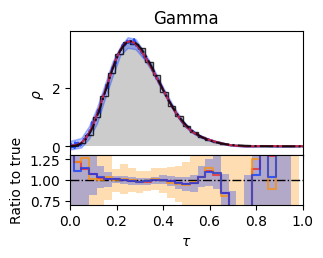

In [26]:
def set_legend(flav):
    if flav == 'rapidity':
        x1 = 0.02
        y1 = 1.5
        x2 = 0.5
        y2 = 1.75
    if flav == 's' or flav == 't':
        x1 = 0.05
        y1 = 0.60
        x2 = 0.02
        y2 = 1.75
    if "gamma" in flav:
        x1 = 0.6
        y1 = 0.66
        x2 = 0.6
        y2 = 1.5
    if 'multi-gauss' in fit_name:
        x1 = 0.75
        y1 = 0.65
        x2 = 0.75
        y2 = 1.75      
    return x1, y1, x2, y2

colors = ['#FF8F01', '#0032FF']
exact_color = "#F01F1F"

def plot_pdf(label, save_as):


    f, (a0, a1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [5, 2]}, sharex=True)
    a0.set_title(f'{label}', fontsize=12)

    f.set_figheight(10 * WIDTH * 6/8)
    f.set_figwidth(10 * WIDTH)

    a0.hist(sample, color='black', alpha=0.2, bins=NBINS, cumulative=False, density=True, label='Data', histtype='bar')
    a0.hist(sample, color='black', alpha=0.8, bins=NBINS, cumulative=False, density=True, histtype='step')

    color_up = "#0032FF"
    a0.plot(xarr, np.mean(noisy_de, axis=0), color=color_up, ls='-', lw=1.5, alpha=0.8)
    a0.fill_between(xarr[idx_noise], int_noise_min, int_noise_max, color=color_up, alpha=0.3)
    a0.plot(xarr[1:], de[1:], color=exact_color, ls='-', lw=1.5, alpha=0.8)


    pc0 = create_box_collection(xarr[idx_noise], int_noise_min, int_noise_max, "blue")
    #a0.add_collection(pc0)

    if not hep:
        a0.plot(xarr, labels, color='black', ls='-.', lw=1.5, label='Target', alpha=0.8)

    if fit_name == 'multi-gauss':
        ratio_idx[-1] = len(xarr) - 1
        
    # Add at 1 the line with the exact result
    a1.axhline(1.0, color='black', lw=1, ls='-.')
    

    # For the time being, skip some bins
    a1.step(xarr[idx], int_exact, color=exact_color, label='Exact simulation', alpha=0.7, lw=1.5)

    # Enable this to get the boxes 
    for i in range(len(Nshots)):
        color = colors[i]
        a1.step(xarr[idx], integrated_central[i], alpha=0.7, color=color, lw=1.5, label=f"{Nshots[i]}")
        ip = integrated_max[i]
        im = integrated_min[i]
        xx = xarr[idx]
        #ip = int_noise_max/labels[idx_noise]
        #im = int_noise_min/labels[idx_noise]
        #xx = xarr[idx_noise]
        pc = create_box_collection(xx, im, ip, color)
        a1.add_collection(pc)
            

    a1.set_ylim(0.7,1.3)
    plt.xlim(0,1)
    
    a1.set_xlabel(r'$\tau$')
    a1.set_ylabel("Ratio to true")
    a0.set_ylabel(r'$\rho$')

    x1, y1, x2, y2 = set_legend(flav)

    #leg0 = a0.legend(loc=(x1, y1), prop={'size': 9}, title=r'Target values')
    #leg1 = a1.legend(loc=(x2, y2), prop={'size': 7.5}, title=r'Simulations')
    
    #leg0._legend_box.align = "left"
    #leg1._legend_box.align = "left"
    
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.savefig(f'{path}PDF_{save_as}.pdf', bbox_inches='tight')
    
# BE SURE TO CHANGE THE LABEL ARGUMENT
plot_pdf(plot_label, save_as)
plt.savefig("PDF.pdf", bbox_inches="tight")

In [28]:
xarr[idx]

array([0.016, 0.048, 0.082, 0.116, 0.148, 0.182, 0.216, 0.248, 0.282,
       0.316, 0.35 , 0.382, 0.416, 0.45 , 0.482, 0.516, 0.55 , 0.582,
       0.616, 0.65 , 0.684, 0.716, 0.75 , 0.784, 0.816, 0.85 , 0.884,
       0.916, 0.95 , 0.984])

In [29]:
for i in range(6,12,1):
    val = integrated_central[1][i]
    err = integrated_central[1][i]- integrated_min[1][i]
    print(f"{val} pm {err}, thus Err={err/val}")

1.0082185168697726 pm 0.04587212425428333, thus Err=0.04549819655832451
1.0008594819042878 pm 0.0522957490704824, thus Err=0.05225084041865874
0.9913479922823418 pm 0.04887462955802446, thus Err=0.049301183780583756
0.9767394487126344 pm 0.04264213456077248, thus Err=0.04365763522398509
0.9840513346438002 pm 0.03929751628714384, thus Err=0.03993441693910051
0.9949688179285104 pm 0.04563163489182598, thus Err=0.04586237686004011


In [30]:
def clean_instabilities(array):
    for i in range(len(array)):
        if array[i] < 0:
            array[i] *= -1
    return array

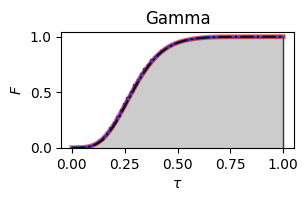

In [31]:
def plot_cdf(label, save_as):

    plt.figure(figsize=(10 * WIDTH, 10 * WIDTH * 4/8))
    plt.title(f'{label}')
    plt.hist(normed_sample, color='black', alpha=0.2, bins=62, cumulative=True, density=True, label='Data', histtype='bar')
    plt.hist(normed_sample, color='black', alpha=0.8, bins=62, cumulative=True, density=True, histtype='step')
    if hep:
        plt.plot(xmeas[1:], e_labels, color='orange', ls='--', label='qGAN data', alpha=0.7)
    plt.plot(xarr, clean_instabilities(e), color=exact_color, ls='-', lw=3.5, label='Exact simulation', alpha=0.7)
    plt.plot(xarr, clean_instabilities(np.mean(noisy_e, axis=0)), color=colors[1], ls='-', lw=2, label=f'{Nshots[1]}', alpha=0.7)

    if not hep:
        plt.plot(xarr, e_labels, ls='-.', lw=1.5, label='Target', alpha=0.8, color="black")

    plt.xlabel(r'$\tau$')
    plt.ylabel(r'$F$')
    
    plt.ylim((0,1.04))

    #plt.legend(loc=(0.02,0.35), prop={'size': 7.5}, framealpha=1)

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.savefig(f'{path}CDF_{save_as}.pdf', bbox_inches="tight")

plot_cdf(plot_label, save_as)